In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from scipy.optimize import curve_fit
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

from wave_optics_propagation_enhanced.classical_numerics import (
    classical_numerics_simulation,
    thin_lens_simulation,
)
from wave_optics_propagation_enhanced.parameters import ExperimentParameters
from wave_optics_propagation_enhanced.result import ExperimentResult

In [2]:
plt.rcParams["text.usetex"] = True
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 14,  # base font size
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "axes.linewidth": 1.2,
    }
)

In [3]:
import os

path = ".result/batch/"
simulations = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]

In [4]:
import pandas as pd

df = pd.DataFrame()
for sim in simulations:
    sim_path = os.path.join(path, sim)
    initial_params = ExperimentParameters.from_file(sim_path)
    new_row = pd.DataFrame([initial_params])
    new_row["path_to_folder"] = sim_path
    df = pd.concat(
        [df, new_row],
        ignore_index=True,
    )
    # df.loc[len(df)] = initial_params

In [5]:
df = df.drop_duplicates(
    subset=df.columns.difference(["experiment_datetime", "path_to_folder", "uuid"])
).reset_index(drop=True)
df.sort_values(by="max_delta", inplace=True)
# df

---


In [6]:
reference_distance = 0.0002


def process_statevector(statevector: np.ndarray) -> np.ndarray:
    return statevector.flatten()


for index, row in df.iterrows():
    params = ExperimentParameters.from_file(path=row["path_to_folder"])
    results = ExperimentResult.from_file(path=row["path_to_folder"])

    reference_distance_index = params.num_of_steps_after_lens * 2 // 3

    reference_statevector = process_statevector(
        results.snapshots[f"step_after_lens_{reference_distance_index + 1}"]
    )

    after_lens_distance = params.step_size_after_lens * (reference_distance_index + 1)
    classical_numerics_result = classical_numerics_simulation(
        params, propagation_after_lens=after_lens_distance
    )
    reference_statevector /= np.linalg.norm(reference_statevector)
    classical_numerics_result /= np.linalg.norm(classical_numerics_result)

    delta = params.max_delta
    overlap = np.abs(np.vdot(reference_statevector, classical_numerics_result))

    df.at[index, "overlap"] = overlap
    df.at[index, "success_probability"] = results.success_probabilities[
        (0 + 1 + params.lens_slices + 1 + reference_distance_index) - 1
    ]

In [7]:
after_lens_distance

0.00020100000000000003

In [8]:
# df.at[0, "path_to_folder"]
# params = ExperimentParameters.from_file(path=df.at[0, "path_to_folder"])
# results = ExperimentResult.from_file(path=df.at[0, "path_to_folder"])
# reference_distance_index = params.num_of_steps_after_lens * 2 // 3
# print(params.step_size_after_lens * (reference_distance_index + 1))

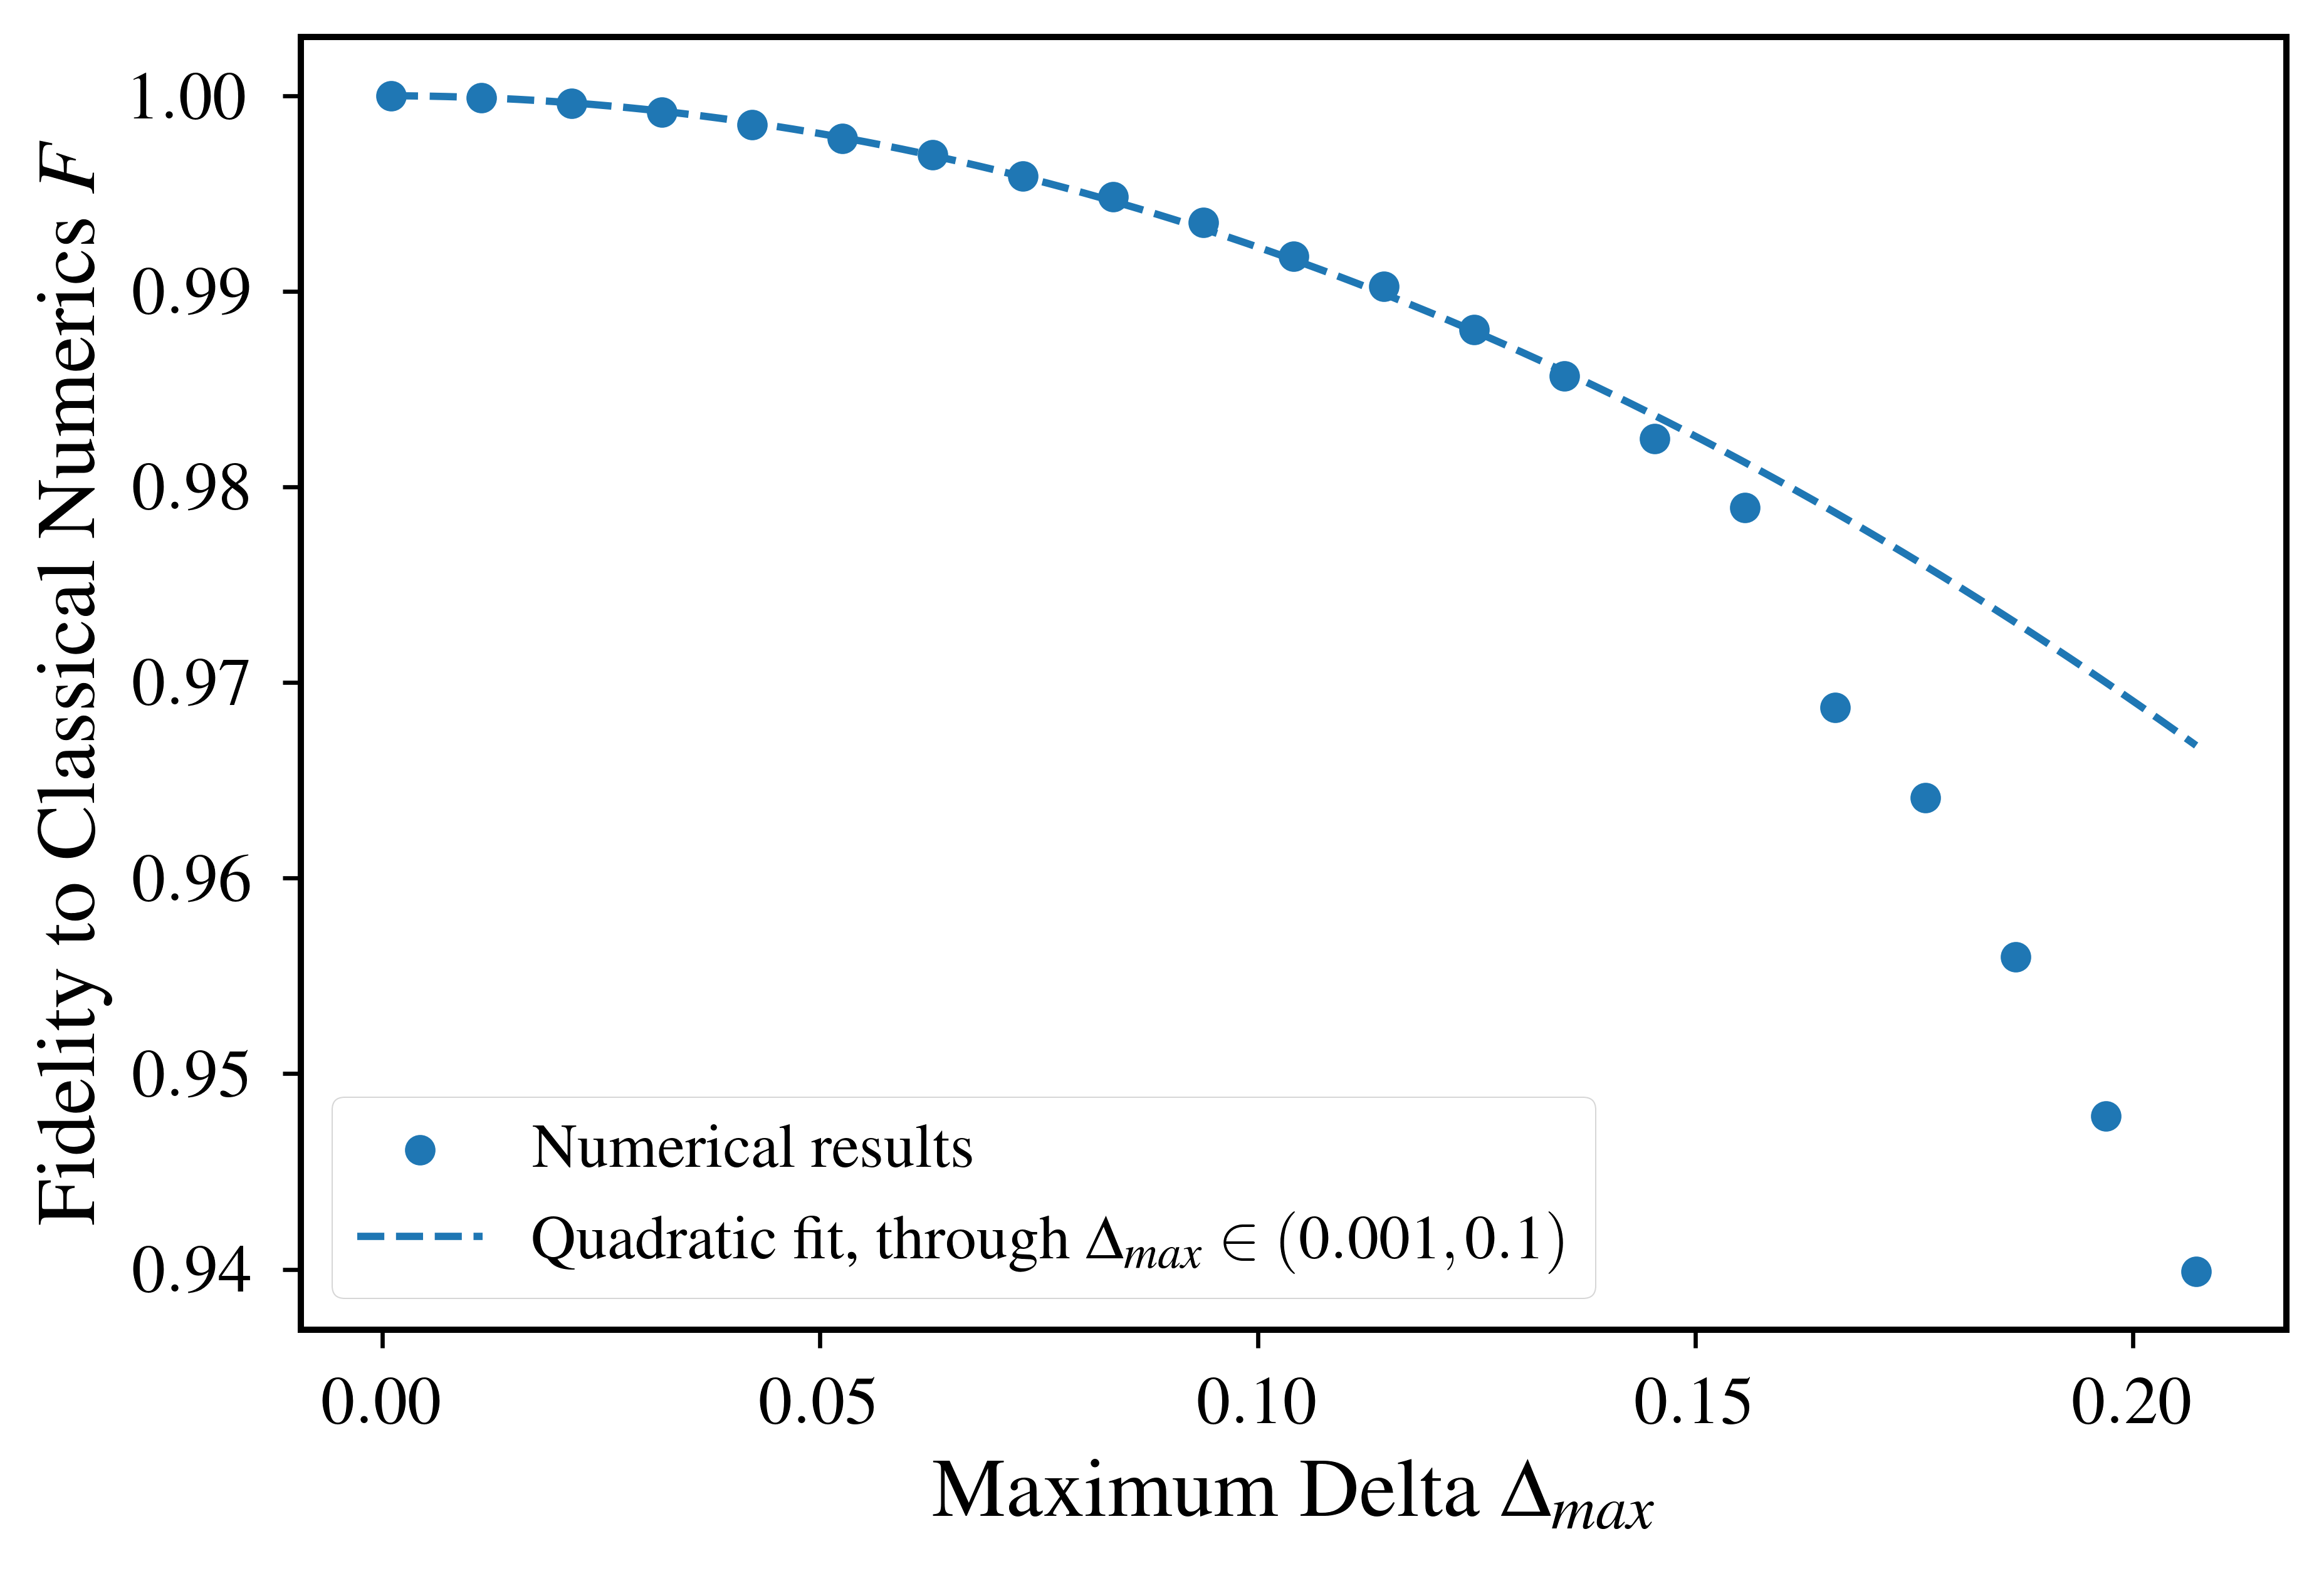

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(1.2 * 6.4, 1.2 * 4.8))
fig, ax = plt.subplots(1, 1)

direct_df = df[df["direct_propagator"] == True]
indirect_df = df[df["direct_propagator"] == False]

NUMS_TO_CUT = 9
NUMS_TO_KEEP_FOR_FITTING = 8

x_data = indirect_df["max_delta"].values[:-NUMS_TO_CUT]
y_data = indirect_df["overlap"].values[:-NUMS_TO_CUT] ** 2

# ax.scatter(
#     direct_df["max_delta"],
#     direct_df["overlap"],
#     label="Direct Propagator",
# )
ax.scatter(
    x_data,
    y_data,
    c="C0",
    label="Numerical results",
)


# fit a quadratic curve to the indirect data
def quad_constrained(x, a):
    return a * x**2 + 1


def sin_fit(x, a):
    return 1 - a * np.sin(x / 2) ** 2


params, _ = curve_fit(
    quad_constrained,
    x_data[:NUMS_TO_KEEP_FOR_FITTING],
    y_data[:NUMS_TO_KEEP_FOR_FITTING],
    # x_data[:],
    # y_data[:],
)
a = params[0]

x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = quad_constrained(x_fit, a)

ax.plot(
    x_fit,
    y_fit,
    c="C0",
    linestyle="--",
    label=r"Quadratic fit, through $\Delta_{max}\in(0.001, 0.1)$",
)

ax.set_xlabel(r"Maximum Delta $\Delta_{max}$")
ax.set_ylabel(r"Fidelity to Classical Numerics $F$")
ax.legend()

fig.tight_layout()
fig.savefig(".output/overlap_with_classical_numerics.pdf")

In [10]:
a

np.float64(-0.7737184954140461)

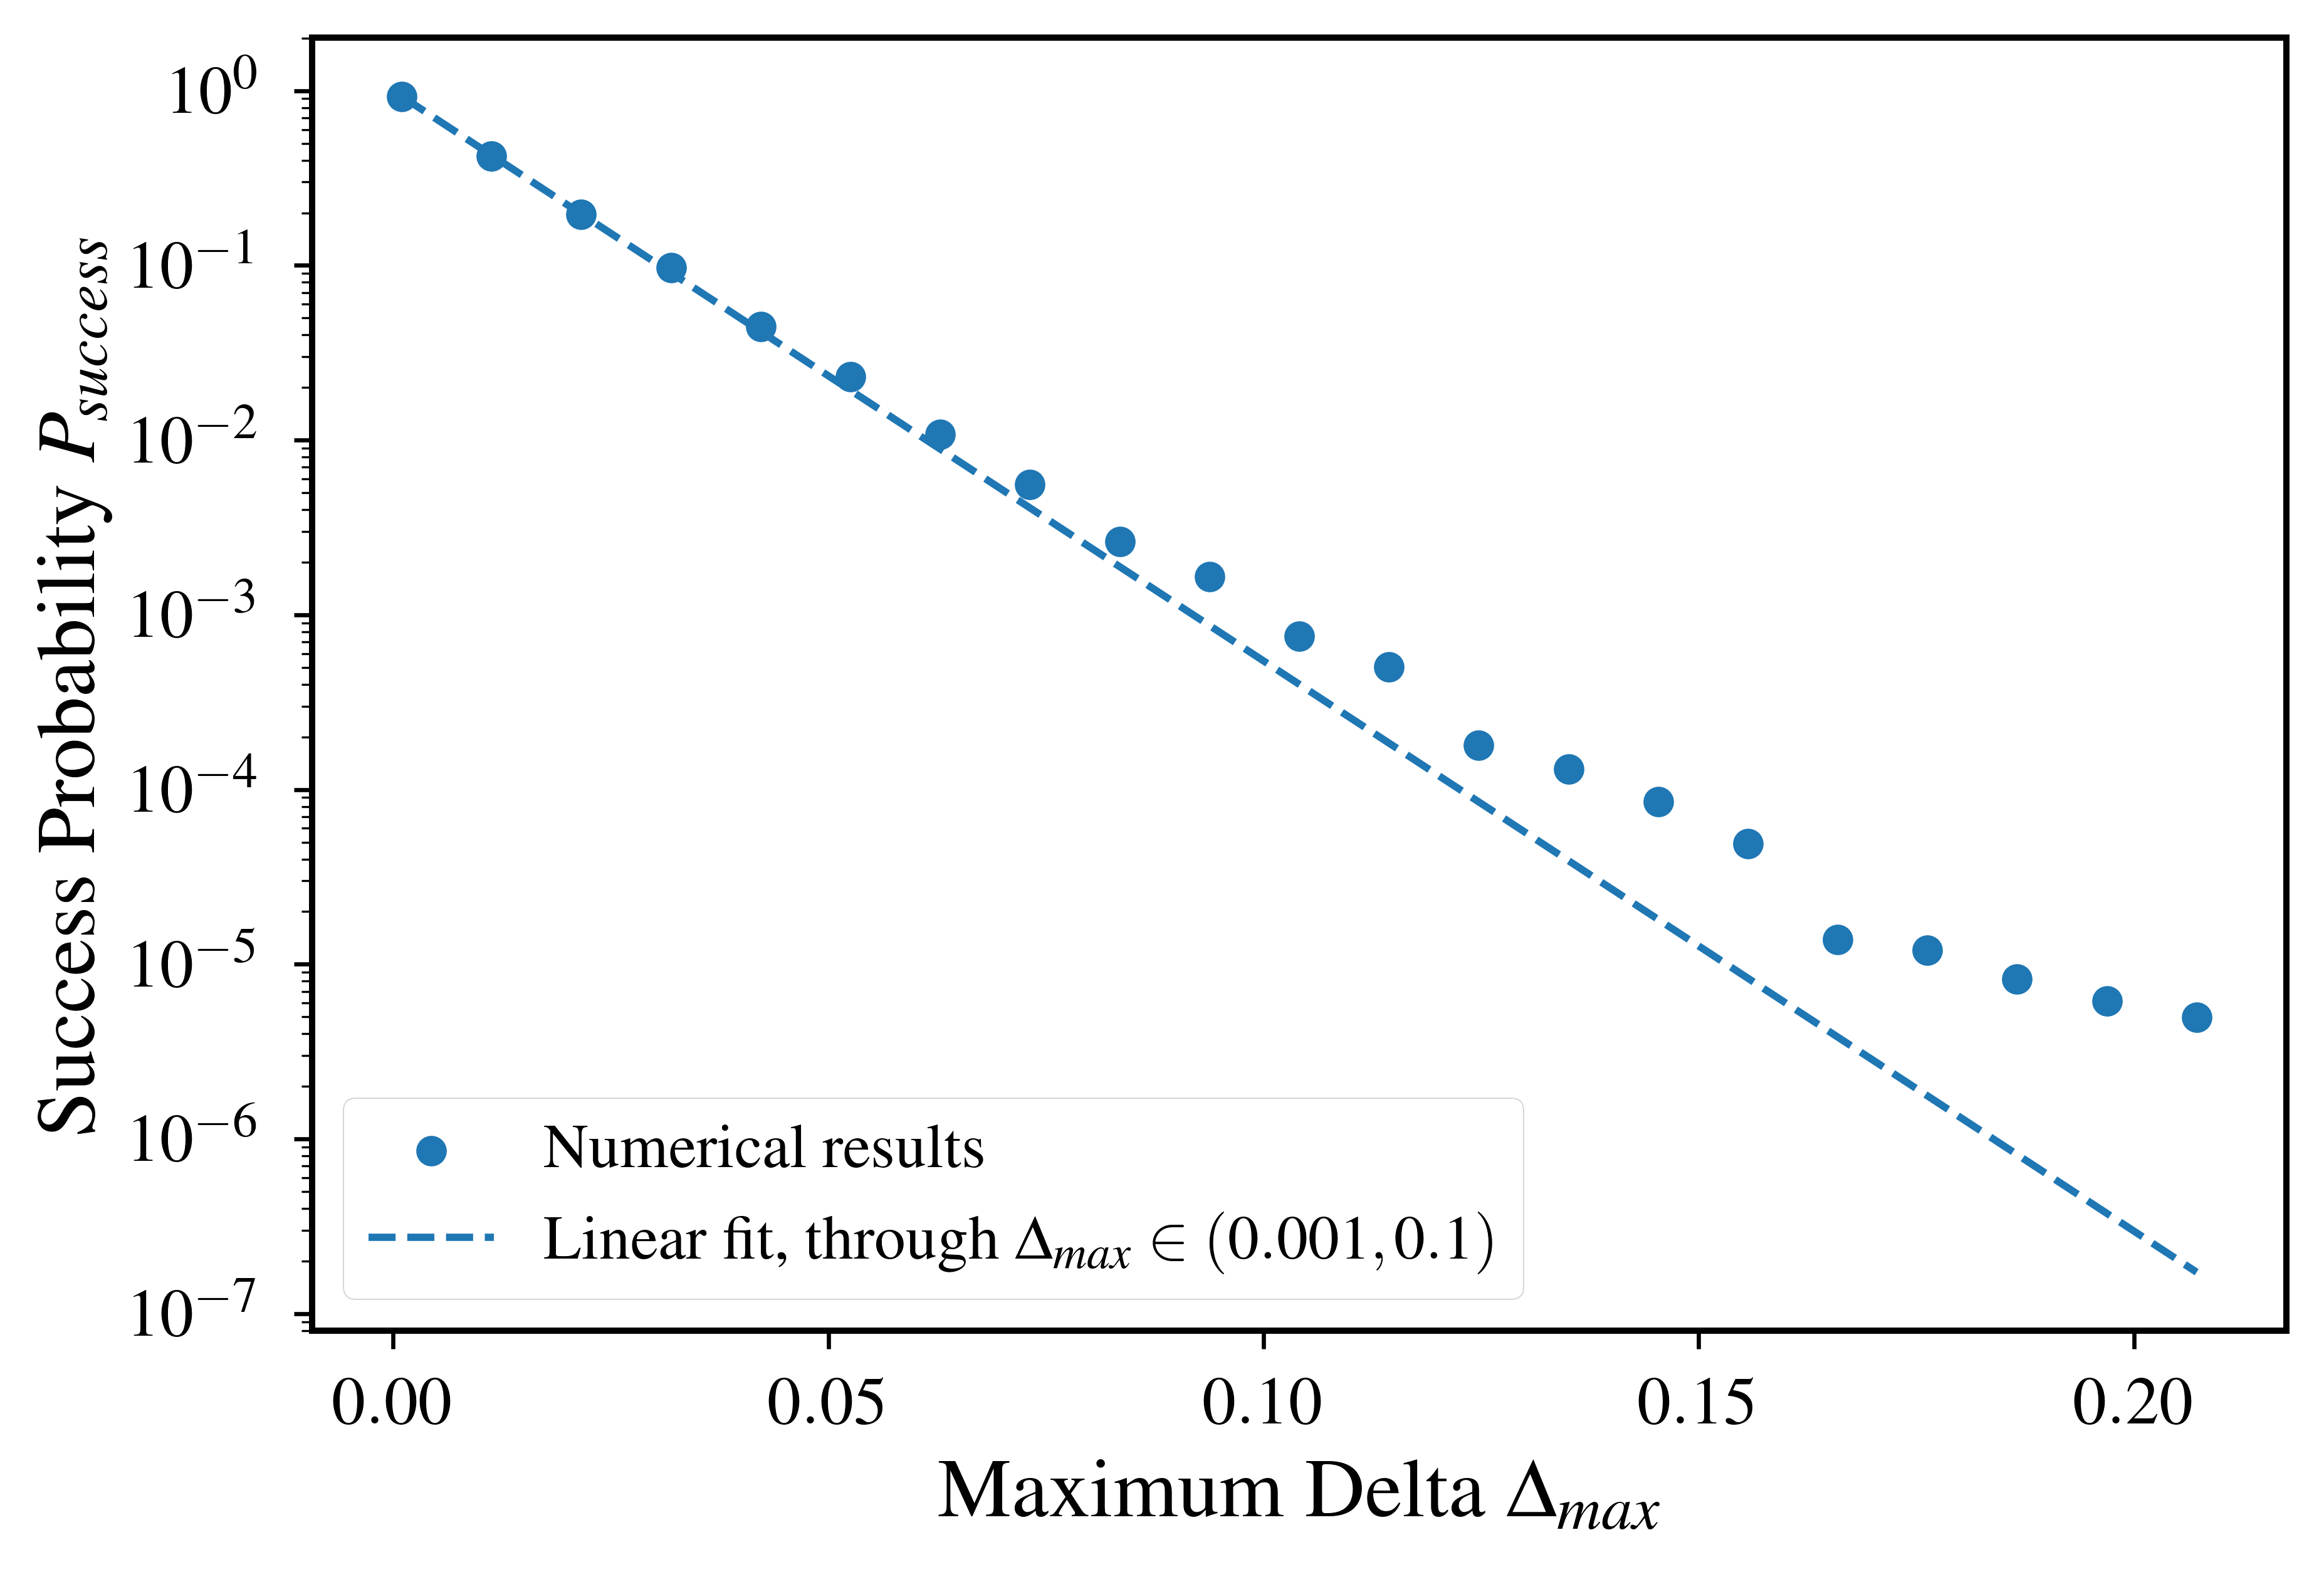

In [16]:
# fig, ax = plt.subplots(1, 1, figsize=(1.2 * 6.4, 1.2 * 4.8))
fig, ax = plt.subplots(1, 1)


direct_df = df[df["direct_propagator"] == True]
indirect_df = df[df["direct_propagator"] == False]

y_data2 = indirect_df["success_probability"].values[:-NUMS_TO_CUT]

ax.scatter(
    x_data,
    y_data2,
    c="C0",
    label="Numerical results",
)

# ax.set_ylim(None, 1.01)
ax.set_yscale("log")


def exp_fit(x, a):
    return np.exp(a * x)


params, _ = curve_fit(
    exp_fit,
    x_data[:NUMS_TO_KEEP_FOR_FITTING],
    y_data2[:NUMS_TO_KEEP_FOR_FITTING],
)
a = params[0]

x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = exp_fit(x_fit, a)

ax.plot(
    x_fit,
    y_fit,
    c="C0",
    linestyle="--",
    label=r"Linear fit, through $\Delta_{max}\in(0.001, 0.1)$",
)


ax.set_xlabel(r"Maximum Delta $\Delta_{max}$")
ax.set_ylabel(r"Success Probability $P_{success}$")
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(".output/success_probability_vs_max_delta.pdf")

In [12]:
np.max(y_data2)

np.float64(0.9257681125128352)

In [13]:
# calculate the slope of the success probability curve in log scale
log_y_data2 = np.log(y_data2)
slope, intercept = np.polyfit(
    x_data[:NUMS_TO_KEEP_FOR_FITTING], log_y_data2[:NUMS_TO_KEEP_FOR_FITTING], 1
)
print(f"Slope of the success probability curve in log scale: {slope}")

Slope of the success probability curve in log scale: -70.78730921968315


In [14]:
# calculate the slope of the success probability curve in log-log scale
log_x = np.log(x_data)
log_y = np.log(y_data2)
slope_log_log, intercept_log_log = np.polyfit(log_x[:5], log_y[:5], 1)
print(f"Slope of the success probability curve in log-log scale: {slope_log_log}")
print(
    f"Intercept of the success probability curve in log-log scale: {intercept_log_log}"
)

Slope of the success probability curve in log-log scale: -0.7136001336059276
Intercept of the success probability curve in log-log scale: -4.717433127018024


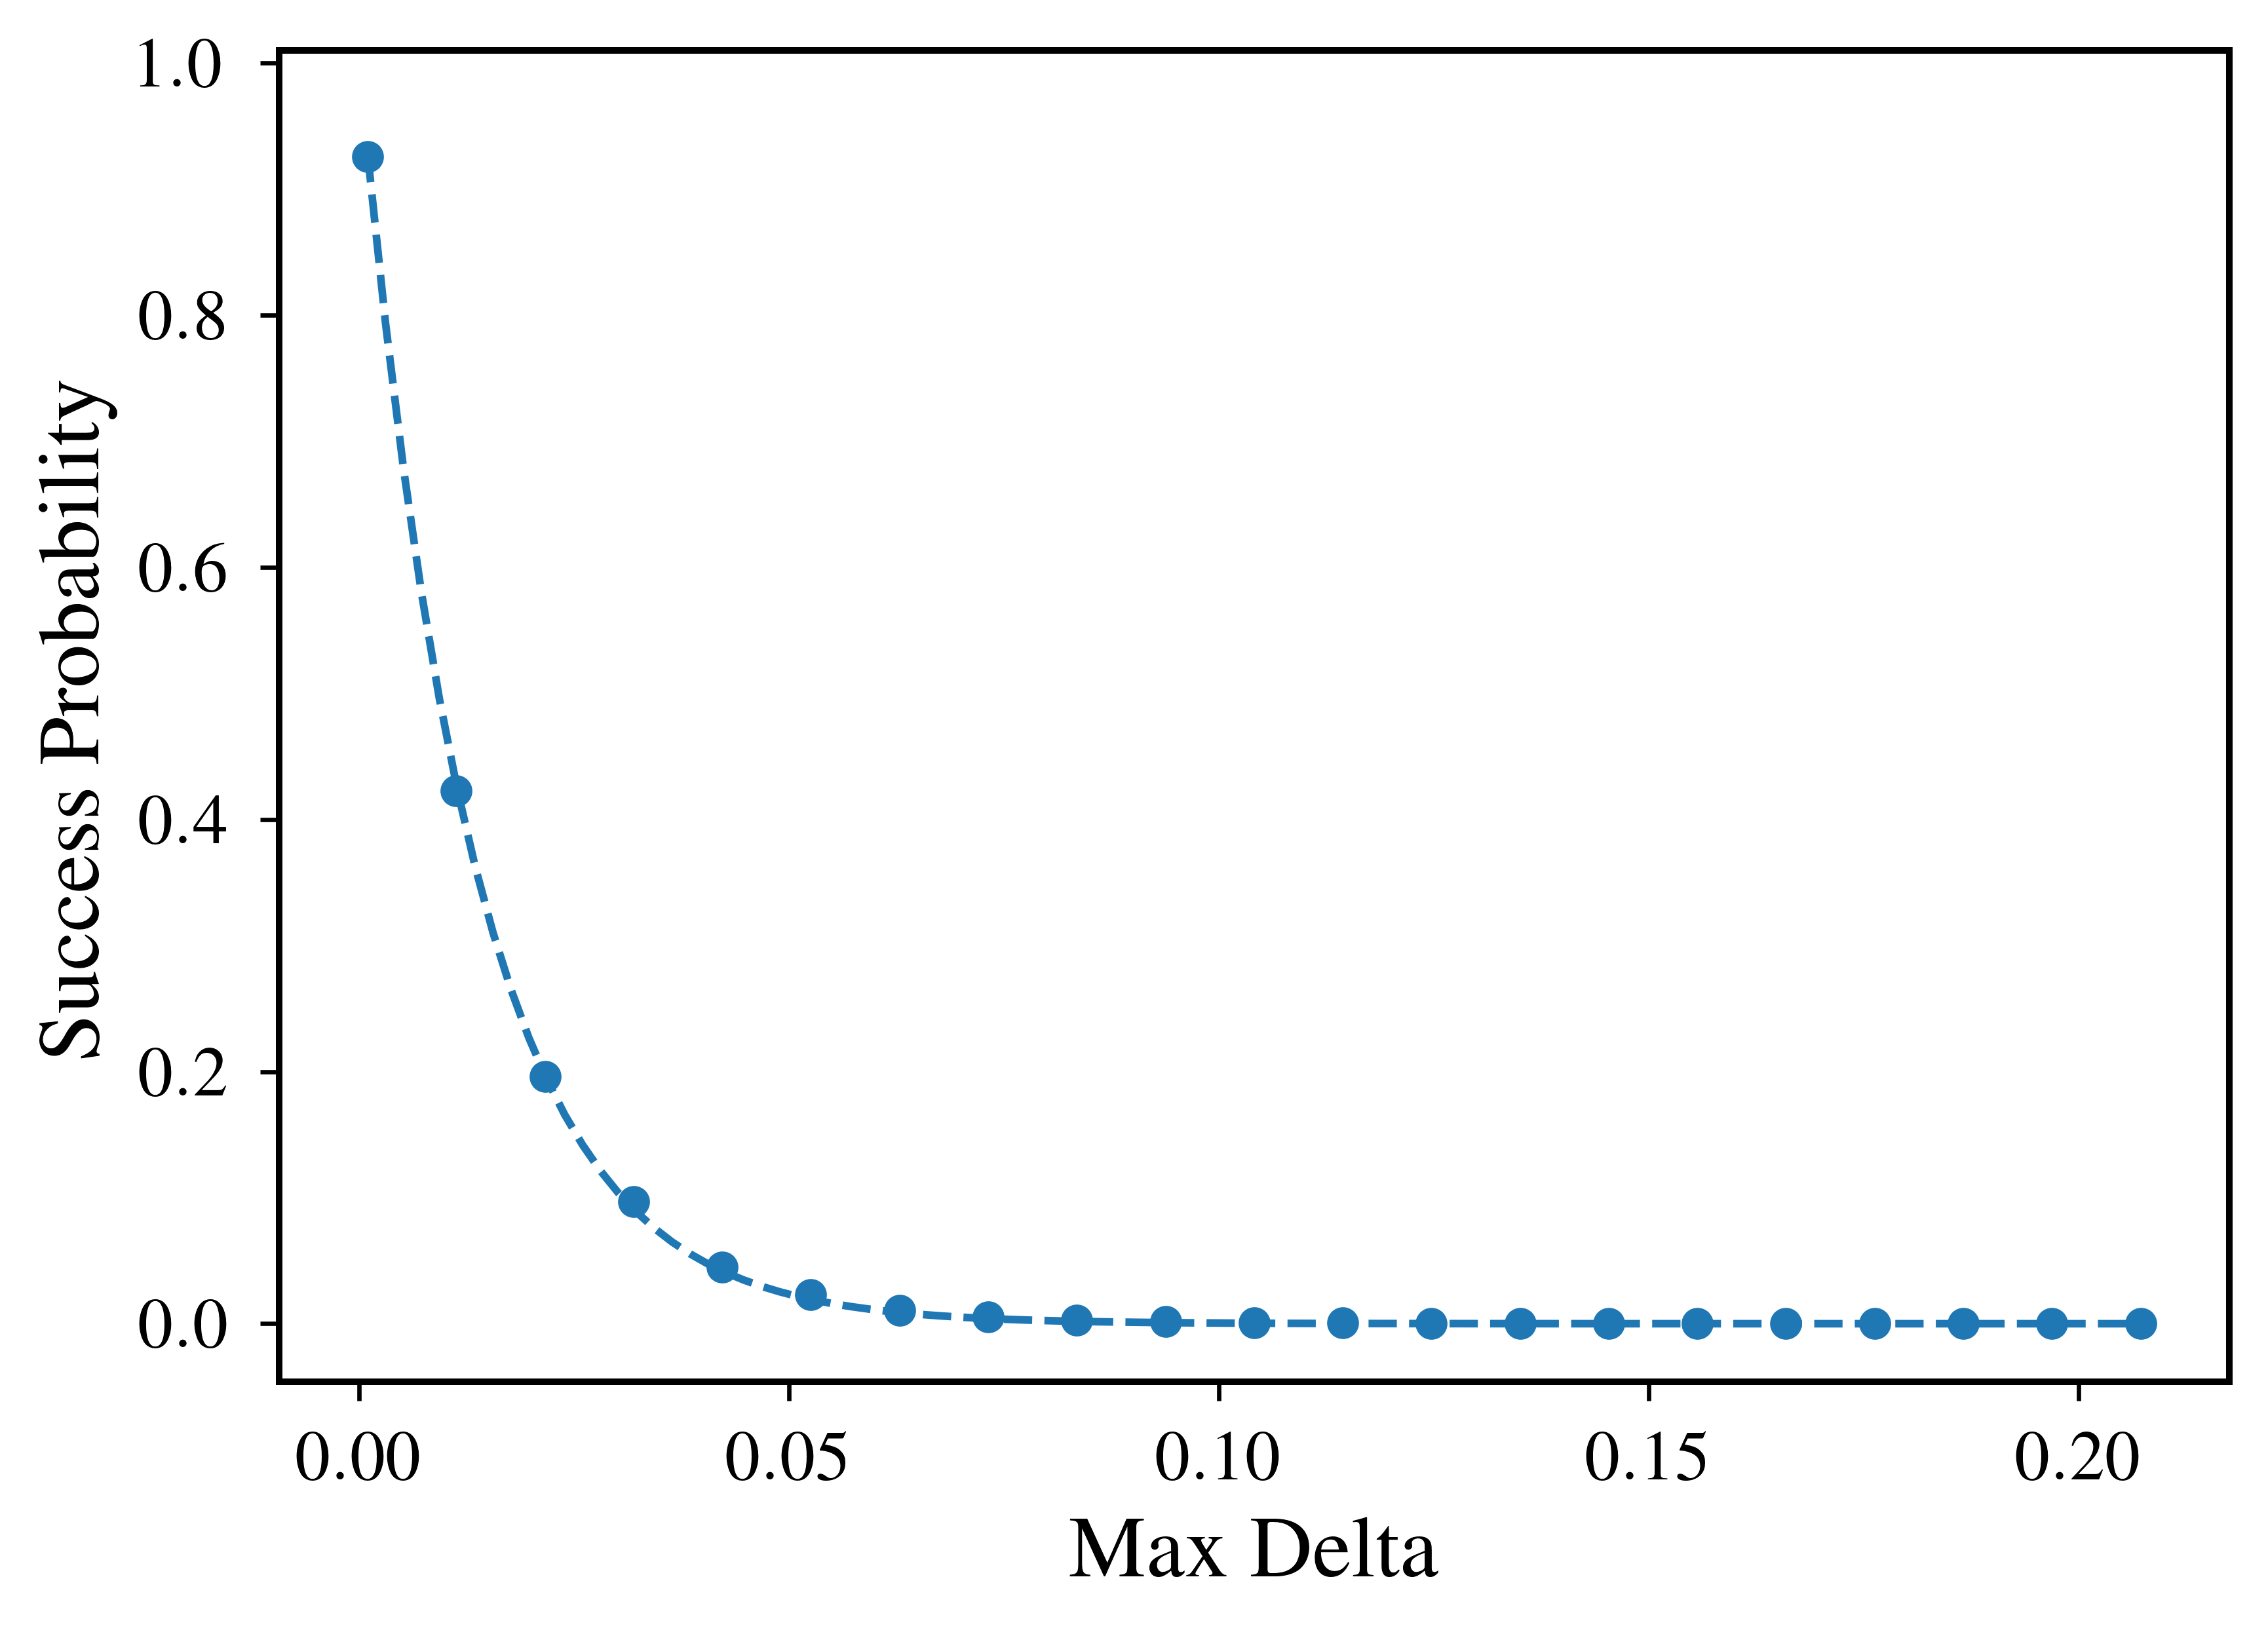

In [15]:
fig, ax = plt.subplots()

direct_df = df[df["direct_propagator"] == True]
indirect_df = df[df["direct_propagator"] == False]

y_data2 = indirect_df["success_probability"].values[:-NUMS_TO_CUT]

ax.scatter(
    x_data,
    y_data2,
    c="C0",
)

ax.set_ylim(None, 1.01)

ax.set_xlabel("Max Delta")
ax.set_ylabel("Success Probability")
# ax.legend()


def exp_fit(x, a):
    return np.exp(a * x)


params, _ = curve_fit(
    exp_fit,
    x_data[:],
    y_data2[:],
)
a = params[0]

x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = exp_fit(x_fit, a)

ax.plot(
    x_fit,
    y_fit,
    c="C0",
    linestyle="--",
    label=r"Exponential fit, through $\Delta_{max}\in(0.001, 0.1)$",
)